## 5.3 랭그래프로 에이전트 설계하고 구현하기

### 5.3.1 [실습] 답변을 생성하는 기본 그래프 구현하기

In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from typing import TypedDict, Annotated
from operator import add

class InputState(TypedDict):
    question: str

class OutputState(TypedDict):
    answer: str

class OverallState(TypedDict):
    messages: Annotated[list[str], add]
    question: str
    answer: str

In [3]:
from langgraph.graph import StateGraph

graph_builder = StateGraph(
	OverallState,
	input_schema=InputState,
	output_schema=OutputState
)

In [4]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o")

def chatbot(state: InputState) -> OverallState:
    question = state["question"]
    response = llm.invoke(question)
    return {
        "answer":response.content,
        "messages": [question, response.content]
    }

graph_builder.add_node("chatbot", chatbot)

In [5]:
from langgraph.graph import START, END

graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)
graph = graph_builder.compile()

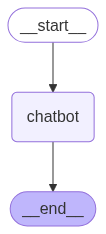

In [6]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [7]:
graph.invoke({"question": "대한민국의 수도는 어디인가요?"})

{'answer': '대한민국의 수도는 서울특별시입니다.'}

### 5.3.2 [실습] 조건이 추가된 그래프 구현하기

In [8]:
from typing import TypedDict, Annotated
from operator import add

class State(TypedDict):
    messages: Annotated[list[str], add]
    question_length: int

In [9]:
from langgraph.graph import StateGraph

graph_builder = StateGraph(State)

In [10]:
def guardrail(state: State) -> State:
    question_length = len(state["messages"][-1])
    return {
        "question_length": question_length
    }

graph_builder.add_node("guardrail", guardrail)

In [11]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o")

def chatbot(state: State) -> State:
    question = state["messages"][-1]
    response = llm.invoke(question)
    return {
        "messages": [response.content]
    }

graph_builder.add_node("chatbot", chatbot)

In [12]:
def routing_function(state: State) -> str:
    if state["question_length"] > 3:
        return "chatbot"
    else:
        return END

graph_builder.add_conditional_edges(
    "guardrail",
    routing_function,
    {"chatbot": "chatbot", END: END}
)

In [13]:
graph_builder.add_edge(START, "guardrail")
graph_builder.add_edge("chatbot", END)
graph = graph_builder.compile()

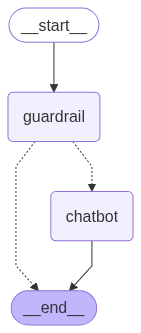

In [14]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [15]:
graph.invoke({"messages":["ㅇ"]})

{'messages': ['ㅇ'], 'question_length': 1}

In [16]:
graph.invoke({"messages":["안녕하세요"]})

{'messages': ['안녕하세요', '안녕하세요! 어떻게 도와드릴까요?'], 'question_length': 5}